## Initial Data Inspection and data cleaning: For developing a better understanding of the data, one would generally do the following checks: 
### Whether the data has 

- duplicates
- missing values
- irrelevant(erroneous entries) values
- Outliers



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv(r'C:\Users\hp\1736848608_rolling_stones_spotify (1)\rolling_stones_spotify.csv', index_col = 0)

In [3]:
data.head()

,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1610 entries, 0 to 1609
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1610 non-null   object 
 1   album             1610 non-null   object 
 2   release_date      1610 non-null   object 
 3   track_number      1610 non-null   int64  
 4   id                1610 non-null   object 
 5   uri               1610 non-null   object 
 6   acousticness      1610 non-null   float64
 7   danceability      1610 non-null   float64
 8   energy            1610 non-null   float64
 9   instrumentalness  1610 non-null   float64
 10  liveness          1610 non-null   float64
 11  loudness          1610 non-null   float64
 12  speechiness       1610 non-null   float64
 13  tempo             1610 non-null   float64
 14  valence           1610 non-null   float64
 15  popularity        1610 non-null   int64  
 16  duration_ms       1610 non-null   int64  
dtype

#### Missing Values

In [5]:
data.isnull().sum()

name                0
album               0
release_date        0
track_number        0
id                  0
uri                 0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64

#### Duplicates

In [6]:
data.duplicated(['id']).sum()

0

#### Conversion of date column to datetime type

In [7]:
data.release_date = pd.to_datetime(data.release_date)

#### Check for count of unique values in object columns

In [8]:
obj_cols = data.select_dtypes('object').columns
for var in obj_cols:
  print('{} : {} '.format(var, data[var].nunique()))

name : 954 
album : 90 
id : 1610 
uri : 1610 


In [9]:
data.track_number.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47], dtype=int64)

In [10]:
data.track_number = data.track_number.astype('category')

#### id and uri have only unique values hence can be removed from the data 


In [11]:
new_data = data.drop(columns = ['id', 'uri'])

## Checking for outliers in numerical variables using descriptive stats looking at the difference between the mean and min & max values of variables.

In [12]:
new_data.describe()

,release_date,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1610,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,1992-04-23 12:57:14.534161536,0.250475,0.468860,0.792352,0.164170,0.49173,-6.971615,0.069512,126.082033,0.582165,20.788199,257736.488199
min,1964-04-16 00:00:00,0.000009,0.104000,0.141000,0.000000,0.02190,-24.408000,0.023200,46.525000,0.000000,0.000000,21000.000000
25%,1970-09-04 00:00:00,0.058350,0.362250,0.674000,0.000219,0.15300,-8.982500,0.036500,107.390750,0.404250,13.000000,190613.000000
50%,1986-03-24 00:00:00,0.183000,0.458000,0.848500,0.013750,0.37950,-6.523000,0.051200,124.404500,0.583000,20.000000,243093.000000
75%,2017-12-01 00:00:00,0.403750,0.578000,0.945000,0.179000,0.89375,-4.608750,0.086600,142.355750,0.778000,27.000000,295319.750000
max,2022-06-10 00:00:00,0.994000,0.887000,0.999000,0.996000,0.99800,-1.014000,0.624000,216.304000,0.974000,80.000000,981866.000000
std,NaN,0.227397,0.141775,0.179886,0.276249,0.34910,2.994003,0.051631,29.233483,0.231253,12.426859,108333.474920


In [13]:
num_vars = new_data.select_dtypes(include = ['float', 'int']).columns
len(num_vars)

11

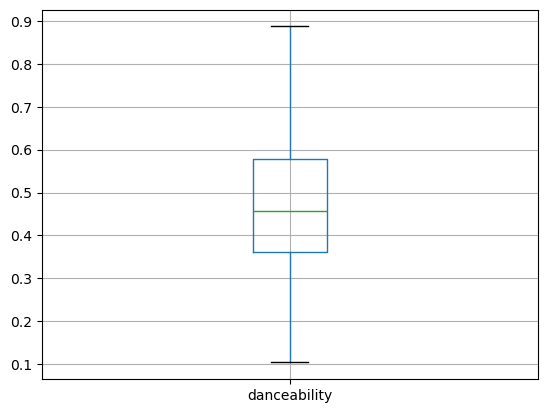

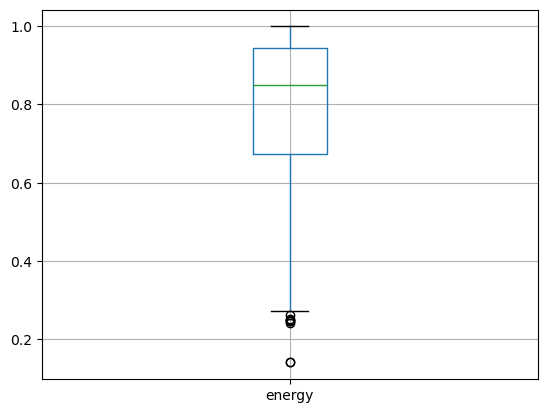

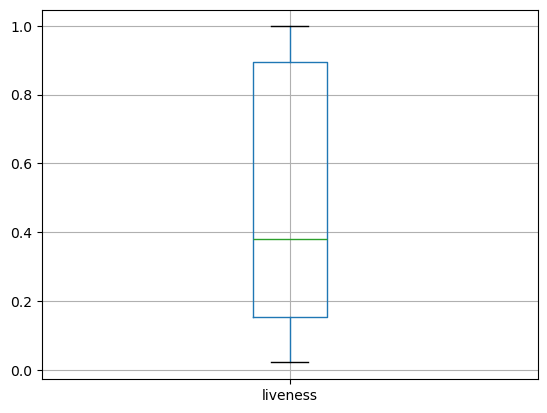

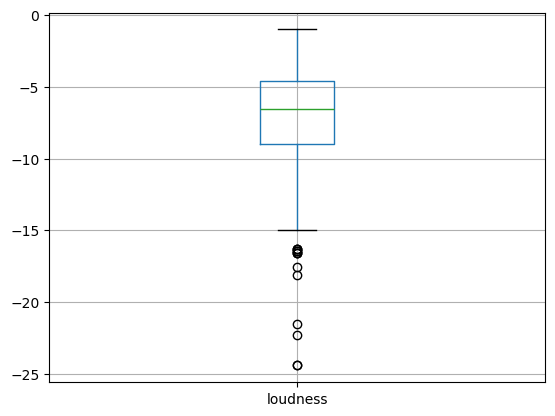

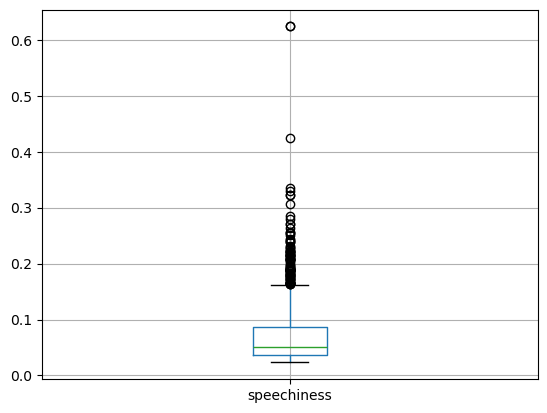

In [27]:
#check for any outlier
new_data[['danceability']].boxplot()
plt.show()
new_data[['energy']].boxplot()
plt.show()
new_data[['liveness']].boxplot()
plt.show()
new_data[['loudness']].boxplot()
plt.show()
new_data[['speechiness']].boxplot()
plt.show()

In [30]:
q1,q3=new_data.loudness.quantile((0.25,0.75))
iqr=q3-q1
min=q1-1.5*iqr
max=q3+1.5*iqr
new_data=new_data[new_data.loudness<max]

In [31]:
q1,q3=new_data.speechiness.quantile((0.25,0.75))
iqr=q3-q1
min=q1-1.5*iqr
max=q3+1.5*iqr
new_data=new_data[new_data.speechiness<max]

In [32]:
q1,q3=new_data.energy.quantile((0.25,0.75))
iqr=q3-q1
min=q1-1.5*iqr
max=q3+1.5*iqr
new_data=new_data[new_data.energy<max]

In [33]:
new_data.isnull().sum()

name                0
album               0
release_date        0
track_number        0
id                  0
uri                 0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64

In [36]:
# Safely drop columns if they exist
new_data.drop(['id'], axis=1, inplace=True, errors='ignore')
new_data.drop(['uri'], axis=1, inplace=True, errors='ignore')

In [38]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1518 entries, 0 to 1609
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   name              1518 non-null   object        
 1   album             1518 non-null   object        
 2   release_date      1518 non-null   datetime64[ns]
 3   track_number      1518 non-null   category      
 4   acousticness      1518 non-null   float64       
 5   danceability      1518 non-null   float64       
 6   energy            1518 non-null   float64       
 7   instrumentalness  1518 non-null   float64       
 8   liveness          1518 non-null   float64       
 9   loudness          1518 non-null   float64       
 10  speechiness       1518 non-null   float64       
 11  tempo             1518 non-null   float64       
 12  valence           1518 non-null   float64       
 13  popularity        1518 non-null   int64         
 14  duration_ms       1518 non-nu

## Which 2 albums would you recommend to anyone based on the number of popular songs in an album? Use necessary visualizations to support your answer.



### top 10 songs

In [40]:
new_data.sort_values('popularity', ascending = False)[['name', 'album','popularity']][:10] 

,name,album,popularity
1403,"Paint It, Black",Aftermath,80
1248,Gimme Shelter,Let It Bleed,76
862,Start Me Up - Remastered 2009,Tattoo You (2009 Re-Mastered),76
1472,(I Can't Get No) Satisfaction - Mono Version,Out Of Our Heads,76
901,Beast Of Burden - Remastered 1994,Some Girls,72
1023,Angie,Goats Head Soup (Remastered 2009),71
1122,Wild Horses - 2009 Mix,Sticky Fingers (Remastered),69
893,Miss You - Remastered,Some Girls,69
1256,You Can't Always Get What You Want,Let It Bleed,67
1120,Brown Sugar - 2009 Remaster,Sticky Fingers (Remastered),66


## popularity of an album using avg popularity of the songs

In [23]:
new_data.groupby(['album'])['popularity'].mean().sort_values(ascending = False)[:10]

album
Sticky Fingers (Remastered)                                  46.100000
Some Girls                                                   43.300000
Exile On Main Street (2010 Re-Mastered)                      42.333333
Tattoo You (2009 Re-Mastered)                                42.272727
Beggars Banquet (50th Anniversary Edition)                   40.400000
Aftermath                                                    38.727273
Let It Bleed (50th Anniversary Edition / Remastered 2019)    38.222222
Black And Blue (Remastered 2009)                             37.875000
Goats Head Soup (Remastered 2009)                            37.500000
Out Of Our Heads                                             36.416667
Name: popularity, dtype: float64

### Sticky Fingers (Remastered) and Some Girls are top 2 albums

## What has changed over the years? Perform exploratory data analysis to dive deeper into different features of songs and identify the pattern. Use necessary visualizations to support your points.



In [42]:
new_data.release_date=pd.to_datetime(new_data.release_date)
new_data['year']=pd.DatetimeIndex(new_data['release_date']).year
new_data['year']

0       2022
1       2022
2       2022
4       2022
5       2022
        ... 
1605    1964
1606    1964
1607    1964
1608    1964
1609    1964
Name: year, Length: 1518, dtype: int32

<Axes: >

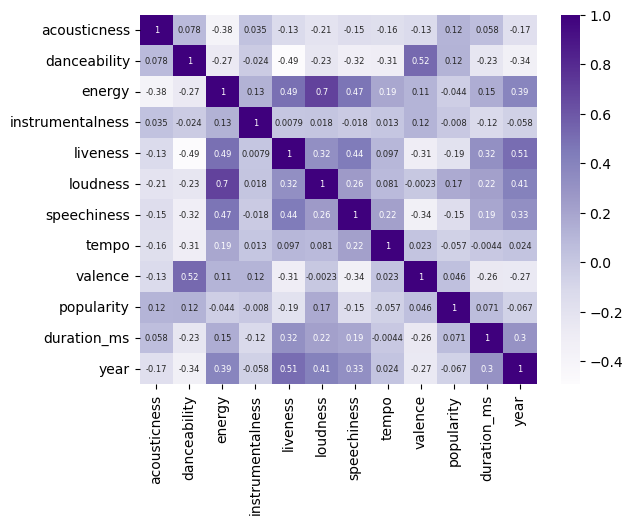

In [51]:
sns.heatmap(new_data.corr(numeric_only=True),annot=True,annot_kws={'size':6},cmap='Purples')

In [45]:
#number of features i.e. n-componants we will take as 5
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [46]:
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [47]:
new_data.columns

Index(['name', 'album', 'track_number', 'acousticness', 'danceability',
       'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness',
       'tempo', 'valence', 'popularity', 'duration_ms', 'year', 'mon'],
      dtype='object')

In [52]:
x=new_data[['danceability','energy','liveness','loudness','speechiness']]

In [48]:
#years=new_data.groupby['year',interval]

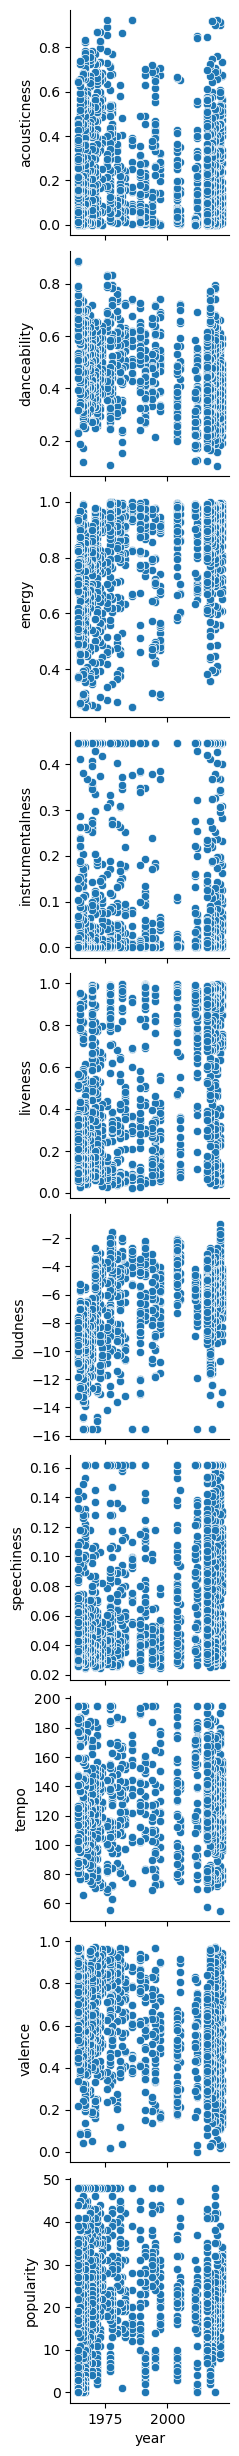

In [54]:
sns.pairplot(new_data,x_vars=['year'],y_vars=['acousticness', 'danceability',
       'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness',
       'tempo', 'valence', 'popularity'])

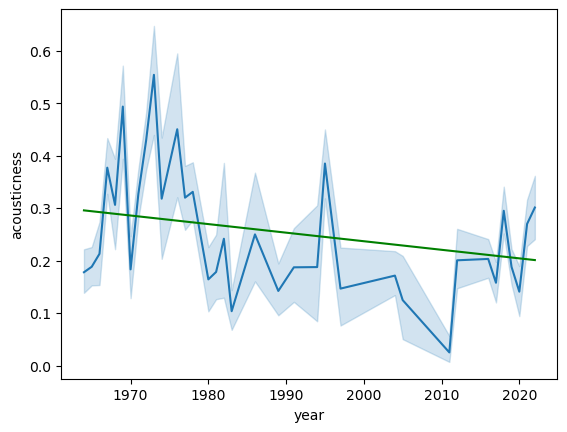

In [53]:
sns.lineplot(x = 'year', y ='acousticness', data = new_data)
z = np.polyfit(new_data['year'],new_data['acousticness'], 1)
p = np.poly1d(z)
plt.plot(new_data['year'],p(new_data['year']),"g")

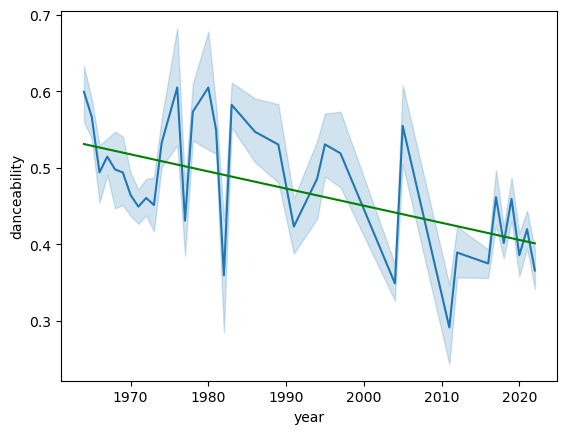

In [55]:
sns.lineplot(x = 'year', y ='danceability', data = new_data)
z = np.polyfit(new_data['year'],new_data['danceability'], 1)
p = np.poly1d(z)
plt.plot(new_data['year'],p(new_data['year']),"g")

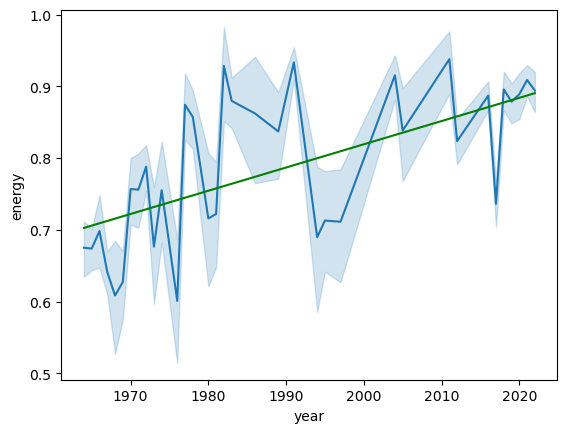

In [56]:
sns.lineplot(x = 'year', y ='energy', data = new_data)
z = np.polyfit(new_data['year'],new_data['energy'], 1)
p = np.poly1d(z)
plt.plot(new_data['year'],p(new_data['year']),"g")

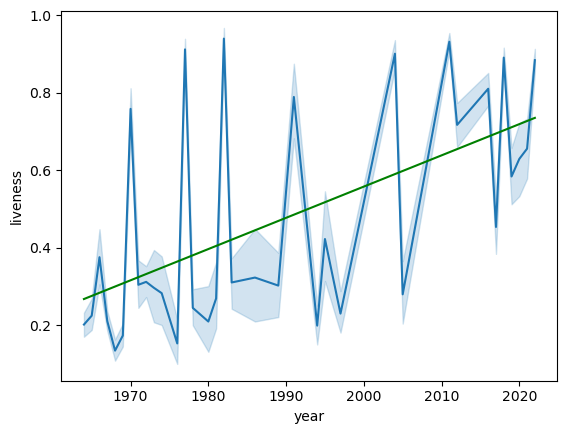

In [57]:
sns.lineplot(x = 'year', y ='liveness', data = new_data)
z = np.polyfit(new_data['year'],new_data['liveness'], 1)
p = np.poly1d(z)
plt.plot(new_data['year'],p(new_data['year']),"g")

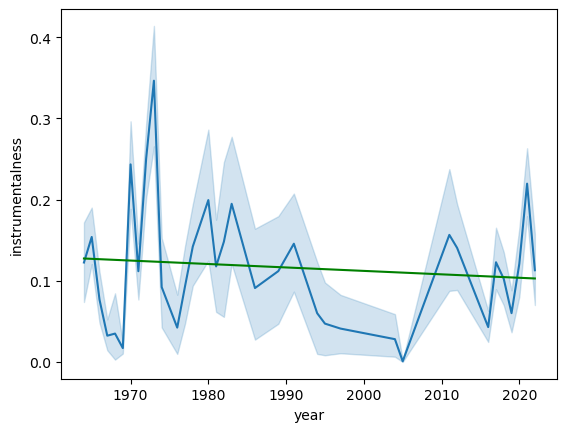

In [59]:
sns.lineplot(x = 'year', y ='instrumentalness', data = new_data)
z = np.polyfit(new_data['year'],new_data['instrumentalness'], 1)
p = np.poly1d(z)
plt.plot(new_data['year'],p(new_data['year']),"g")

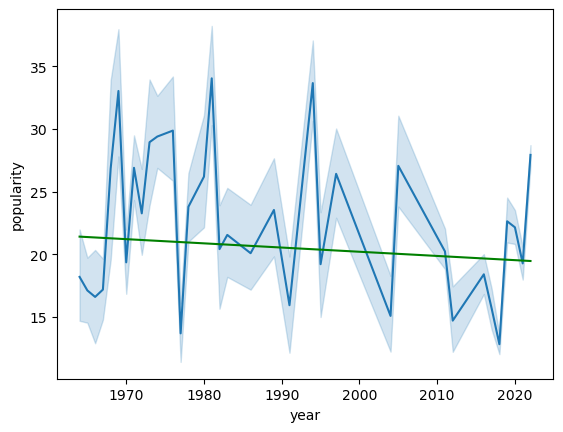

In [58]:
sns.lineplot(x = 'year', y ='popularity', data = new_data)
z = np.polyfit(new_data['year'],new_data['popularity'], 1)
p = np.poly1d(z)
plt.plot(new_data['year'],p(new_data['year']),"g")

### an increasing trend in energy liveliness loudness speechiness and duration
### a decreasing trend in valence and danceability 
### others remain more or less constant over the years

In [ ]:
# How does the popularity of a song relate to different factors? Has this changed over the years?


In [60]:
new_data.year.describe()

count    1610.000000
mean     1991.745963
std        22.440296
min      1964.000000
25%      1970.000000
50%      1986.000000
75%      2017.000000
max      2022.000000
Name: year, dtype: float64

In [ ]:
new_data['year_class'] = pd.cut(new_data.year, 6, labels = [1,2,3,4,5,6])

# Answer: Check for Correlation values across year groups and the trend in them.

## Should we go for dimensionality reduction techniques? share your thoughts and act appropriately.

## Since there are 12 numerical variables we shall go for dimensionality reduction technique.

### PCA : Principal Component Analysis

In [62]:
new_data.loc[:,'acousticness':'duration_ms'].describe()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,0.250366,0.468860,0.792575,0.115692,0.49173,-6.945452,0.066091,125.922829,0.582165,20.483851,251121.135714
std,0.227061,0.141775,0.179177,0.170448,0.34910,2.890694,0.038636,28.798294,0.231253,11.504048,86189.545637
min,0.000009,0.104000,0.267500,0.000000,0.02190,-15.543125,0.023200,54.943250,0.000000,0.000000,33552.875000
25%,0.058350,0.362250,0.674000,0.000219,0.15300,-8.982500,0.036500,107.390750,0.404250,13.000000,190613.000000
50%,0.183000,0.458000,0.848500,0.013750,0.37950,-6.523000,0.051200,124.404500,0.583000,20.000000,243093.000000
75%,0.403750,0.578000,0.945000,0.179000,0.89375,-4.608750,0.086600,142.355750,0.778000,27.000000,295319.750000
max,0.921850,0.887000,0.999000,0.447171,0.99800,-1.014000,0.161750,194.803250,0.974000,48.000000,452379.875000


In [63]:
sc = StandardScaler()

In [64]:
data_std = sc.fit_transform(new_data.loc[:,'acousticness':'duration_ms'])

In [65]:
cor_mat = np.corrcoef(data_std, rowvar = False)

In [66]:
eig_val, eig_vec = np.linalg.eig(cor_mat)

In [67]:
var_cap = sorted((eig_val / eig_val.sum()) *100, reverse = True)

<BarContainer object of 11 artists>

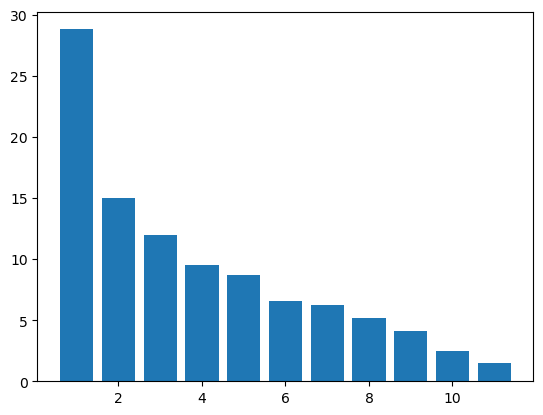

In [68]:
plt.bar(x = range(1,12), height = var_cap)

In [69]:
np.cumsum(var_cap)

array([ 28.80051081,  43.79788811,  55.74659091,  65.24953621,
        73.95501544,  80.50196721,  86.76518148,  91.90686353,
        96.01840241,  98.51330462, 100.        ])

In [70]:
eig_val

array([3.16805619, 1.6497115 , 1.31435731, 0.16353649, 1.04532398,
       0.95760271, 0.27443924, 0.68895357, 0.7201647 , 0.56558503,
       0.45226928])

In [71]:
pca = PCA(n_components = 6)

In [72]:
pca.fit(data_std)

PCA(n_components=6)

In [73]:
pca_data = pca.transform(data_std)

In [74]:
pca_df = pd.DataFrame(pca_data, columns = ['PC{}'.format(i+1) for i in range(6)])

In [75]:
exclude_var = new_data.loc[:,'acousticness':'duration_ms'].columns
obj_cat_data = new_data.loc[:,~new_data.columns.isin(exclude_var)]

In [76]:
final_data = pd.concat([pca_df,obj_cat_data] , axis = 1)
final_data.head(2)

,PC1,PC2,PC3,PC4,PC5,PC6,name,album,track_number,year,mon
0,0.822186,-0.478498,-1.668891,2.121928,-0.091167,2.039259,Concert Intro Music - Live,Licked Live In NYC,1,2022,6
1,1.872676,-0.509072,0.895302,1.398785,0.465070,0.359185,Street Fighting Man - Live,Licked Live In NYC,2,2022,6


In [77]:
final_data.drop(columns = ['name'], inplace = True)

In [78]:
fd = pd.get_dummies(final_data)
fd

,PC1,PC2,PC3,PC4,PC5,PC6,year,mon,album_12 X 5,album_12 x 5,...,track_number_38,track_number_39,track_number_40,track_number_41,track_number_42,track_number_43,track_number_44,track_number_45,track_number_46,track_number_47
0,0.822186,-0.478498,-1.668891,2.121928,-0.091167,2.039259,2022,6,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1.872676,-0.509072,0.895302,1.398785,0.465070,0.359185,2022,6,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2.133075,-0.284416,0.711880,2.196867,0.249026,0.757027,2022,6,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2.770433,-1.750189,0.981314,0.427079,0.445889,1.910846,2022,6,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2.387283,-1.198579,1.067548,0.379010,0.419729,0.509249,2022,6,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,-0.801914,1.774428,-0.227980,-0.570903,2.191042,0.216224,1964,4,False,False,...,False,False,False,False,False,False,False,False,False,False
1606,-0.272951,-0.452083,0.405183,-0.757439,0.573841,0.765050,1964,4,False,False,...,False,False,False,False,False,False,False,False,False,False
1607,-2.384890,0.902735,0.825965,-0.413349,-0.502573,1.652142,1964,4,False,False,...,False,False,False,False,False,False,False,False,False,False
1608,-2.472823,-0.267026,-0.221804,-0.608800,-0.126595,1.541648,1964,4,False,False,...,False,False,False,False,False,False,False,False,False,False


# Perform cluster analysis to create cohorts of songs:

- Identify the right number of clusters
- Use appropriate clustering algorithm
- Define each cluster based on the features



In [79]:
from sklearn.cluster import KMeans

In [80]:
errors = []
for i in range(1,30):
  kmm = KMeans(n_clusters = i)
  kmm.fit(fd)
  errors.append(kmm.inertia_)

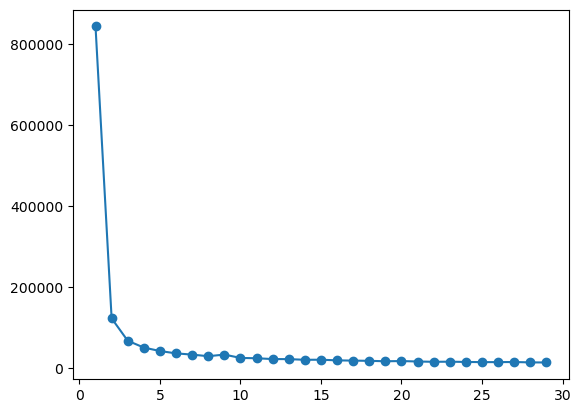

In [81]:
plt.plot(range(1,30), errors)
plt.scatter(range(1,30), errors)

In [82]:
kmm = KMeans(n_clusters = 4)
kmm.fit(fd)

KMeans(n_clusters=4)

In [84]:
fd['clus_label'] = kmm.labels_

In [85]:
fd.groupby('clus_label').mean()

,PC1,PC2,PC3,PC4,PC5,PC6,year,mon,album_12 X 5,album_12 x 5,...,track_number_38,track_number_39,track_number_40,track_number_41,track_number_42,track_number_43,track_number_44,track_number_45,track_number_46,track_number_47
clus_label,,,,,,,,,,,,,,,,,,,,,
0,1.142525,-0.105601,0.071319,-0.078741,-0.182343,-0.029058,2016.658209,8.511940,0.000000,0.000000,...,0.001493,0.001493,0.001493,0.001493,0.001493,0.001493,0.001493,0.001493,0.001493,0.001493
1,-0.431899,0.316531,0.501819,0.385346,0.175818,-0.061352,1975.469780,6.299451,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,-0.110490,0.181048,0.234823,-0.237377,0.094865,0.025803,1992.040268,5.107383,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,-1.385990,-0.167309,-0.621626,-0.122108,0.103131,0.088891,1966.428571,7.201405,0.028103,0.028103,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Cluster Profile

In [86]:
data_new = new_data.drop(columns = 'name')
data_dummy = pd.get_dummies(data_new)
data_dummy.head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,...,track_number_38,track_number_39,track_number_40,track_number_41,track_number_42,track_number_43,track_number_44,track_number_45,track_number_46,track_number_47
0,0.0824,0.463,0.993,0.447171,0.932,-12.913,0.11000,118.001,0.0302,33,...,False,False,False,False,False,False,False,False,False,False
1,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.07590,131.455,0.3180,34,...,False,False,False,False,False,False,False,False,False,False
2,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.11500,130.066,0.3130,34,...,False,False,False,False,False,False,False,False,False,False
3,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.16175,132.994,0.1470,32,...,False,False,False,False,False,False,False,False,False,False
4,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.09300,130.533,0.2060,32,...,False,False,False,False,False,False,False,False,False,False


# Visualization

NameError: name 'data_dummy_copy_2' is not defined

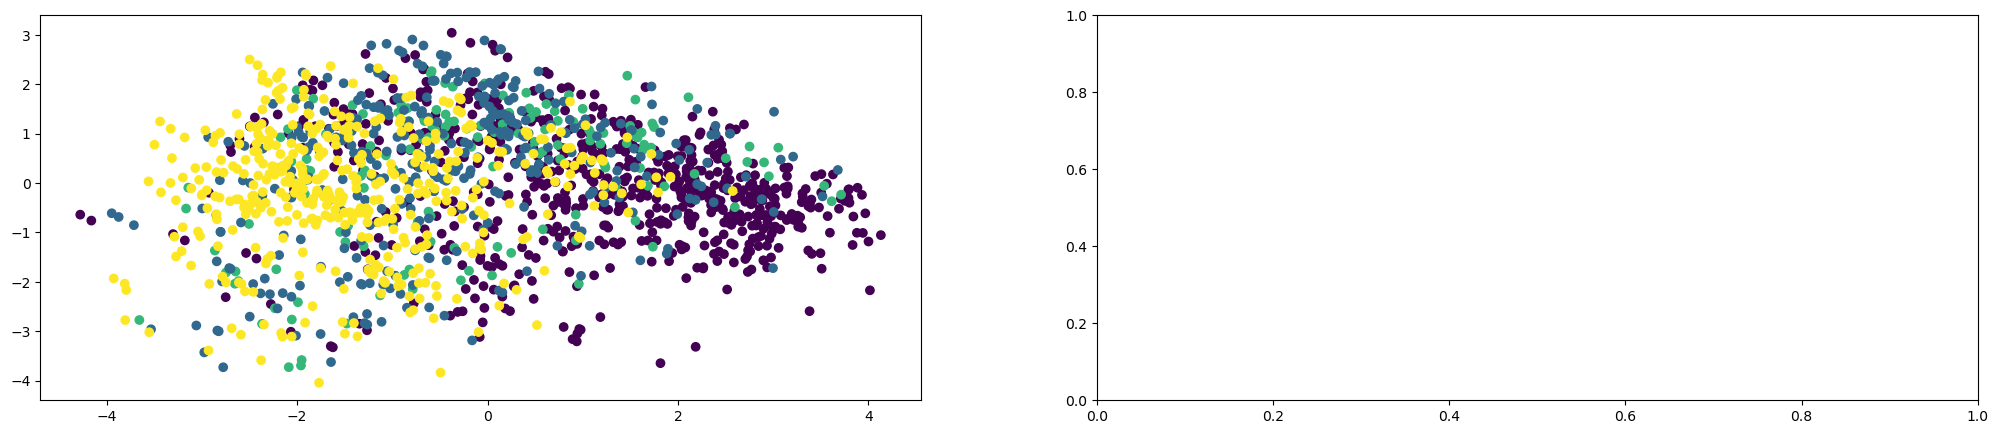

In [88]:
f,ax = plt.subplots(1,2, figsize = (25,5))
# PCA data
ax[0].scatter(x = fd.PC1, y= fd.PC2, c = fd.clus_label)
ax[1].scatter(x = data_dummy_copy_2.acousticness, y= data_dummy_copy_2.danceability, c = data_dummy_copy_2.cluster)
plt.show()

0.5874911249497241
0.5220015074155374
0.4747532744242489
0.4474858879663505
0.4424506572612626
0.4193201998920328
0.4109908376580186
0.39881515990494865
0.3812783621351298


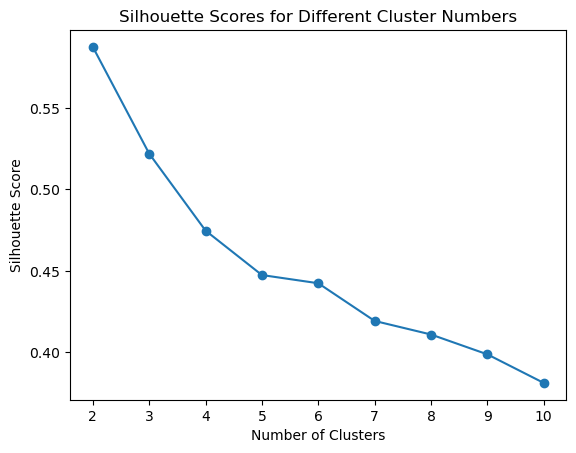

In [89]:
from sklearn.metrics import silhouette_score

# List to store silhouette scores
silhouette_scores = []

# Loop over a range of cluster numbers
for i in range(2, 11):
    model1 = KMeans(n_clusters=i, n_init=10, init='k-means++', random_state=42)
    model1.fit(x)
    labels = model1.labels_  # Cluster labels for the fitted model
    score = silhouette_score(x, labels)# Calculate silhouette score
    print(score)
    silhouette_scores.append(score)

# Plot silhouette scores
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different Cluster Numbers')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()